In [1]:
! pip install pandas
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")

In [2]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# drop CustomerID 
df = df.drop('CustomerID', axis=1)

In [7]:
# encode Gender, Female → 0, Male → 1
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [8]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [9]:
# normalize all values between 0 and 1.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [10]:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


In [11]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(scaled_df)
    
    wcss.append(kmeans.inertia_)

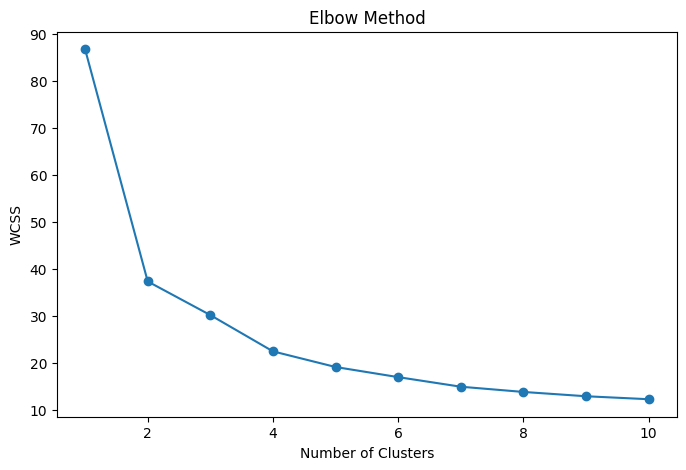

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [13]:
#Silhouette Score
from sklearn.metrics import silhouette_score

scores = []

for i in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    labels = kmeans.fit_predict(scaled_df)
    
    score = silhouette_score(scaled_df, labels)
    
    scores.append(score)
    
    print(f'k={i}, Silhouette Score={score}')

k=2, Silhouette Score=0.5194624832665107
k=3, Silhouette Score=0.3966438735627507
k=4, Silhouette Score=0.36416575223390624
k=5, Silhouette Score=0.37089464698896935
k=6, Silhouette Score=0.37779663738503727
k=7, Silhouette Score=0.35081175707579704
k=8, Silhouette Score=0.3312236599956242
k=9, Silhouette Score=0.3283508549666621
k=10, Silhouette Score=0.3261954593397033


/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ashna/.pyenv/versions/3.13.5/lib/py

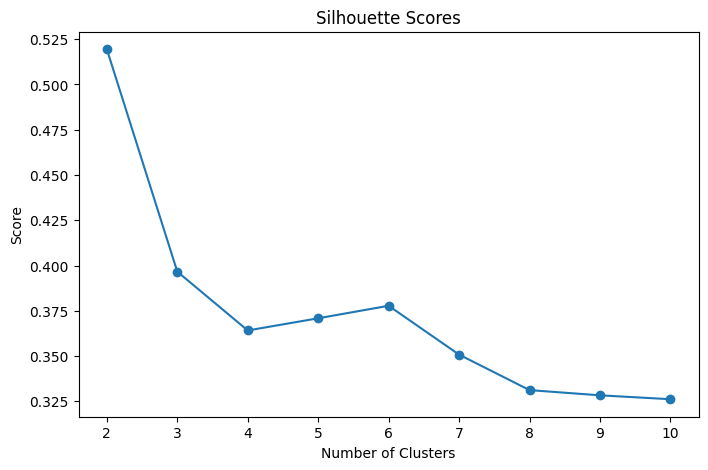

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o')

plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')

plt.show()

In [15]:
# Apply k-Means Clustering
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(scaled_df)

In [16]:
# Add Cluster Column
scaled_df['Cluster'] = clusters

In [17]:
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1.0,0.019231,0.000000,0.387755,3
1,1.0,0.057692,0.000000,0.816327,3
2,0.0,0.038462,0.008197,0.051020,1
3,0.0,0.096154,0.008197,0.775510,2
4,0.0,0.250000,0.016393,0.397959,2


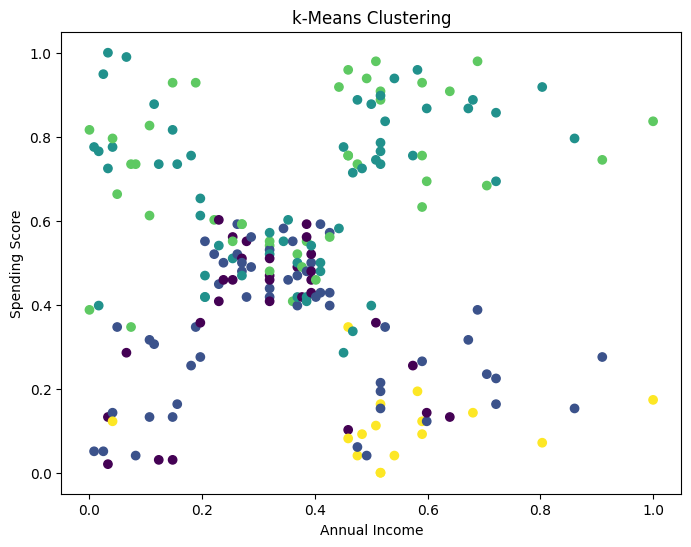

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df['Annual Income (k$)'],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.title('k-Means Clustering')

plt.show()

In [19]:
# Apply Density-Based Spatial Clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.15,
    min_samples=5
)

In [20]:
dbscan_labels = dbscan.fit_predict(
    scaled_df.drop('Cluster', axis=1)
)

In [21]:

scaled_df['DBSCAN_Cluster'] = dbscan_labels

print(scaled_df.head())

   Gender       Age  Annual Income (k$)  Spending Score (1-100)  Cluster  \
0     1.0  0.019231            0.000000                0.387755        3   
1     1.0  0.057692            0.000000                0.816327        3   
2     0.0  0.038462            0.008197                0.051020        1   
3     0.0  0.096154            0.008197                0.775510        2   
4     0.0  0.250000            0.016393                0.397959        2   

   DBSCAN_Cluster  
0              -1  
1               1  
2              -1  
3               0  
4              -1  


In [22]:
print(
    scaled_df['DBSCAN_Cluster'].value_counts()
)

DBSCAN_Cluster
-1    65
 0    34
 2    25
 3    22
 6    18
 5    11
 4     9
 1     6
 8     5
 7     5
Name: count, dtype: int64


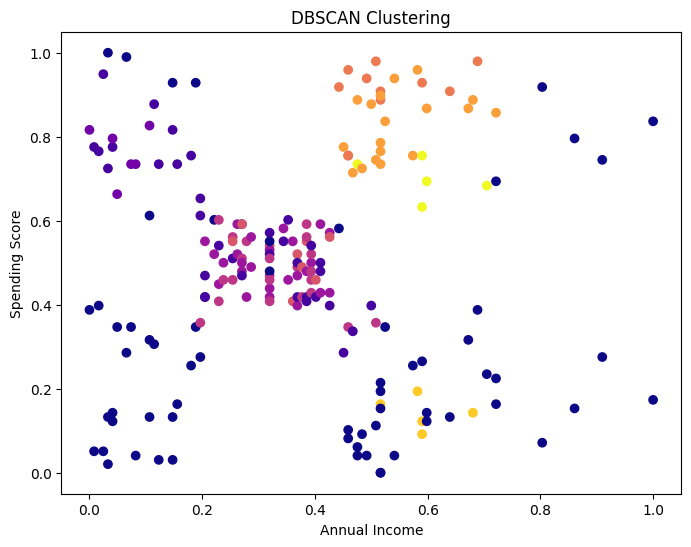

In [23]:
# Visualize DBSCAN Clusters

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df['Annual Income (k$)'],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['DBSCAN_Cluster'],
    cmap='plasma'
)

plt.xlabel('Annual Income')

plt.ylabel('Spending Score')

plt.title('DBSCAN Clustering')

plt.show()

In [ ]:
#k-Means performed better for the Mall Customer dataset because the clusters were compact and well-separated. DBSCAN detected outliers but produced many noise points and fragmented clusters. Therefore, k-Means was more suitable for meaningful customer segmentation.